# Rank Stability & Leaderboard Evolution

Goal: see how algorithm rankings evolve over time and which methods are consistently top.

Expected takeaway: stable leaders vs volatile competitors across steps.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / "combined_wide.csv")
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")
combined["seed"] = combined["seed"].astype(str)

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
metrics = ["pass@1", "pass@8", "pass@32"]

# Rank per step
rank_rows = []
for metric in metrics:
    for step in sorted(agg["Step"].unique()):
        sub = agg[agg["Step"] == step].sort_values(metric, ascending=False)
        for rank, (algo, val) in enumerate(zip(sub["algorithm"], sub[metric]), start=1):
            rank_rows.append({"Step": step, "metric": metric, "algorithm": algo, "rank": rank, "value": val})

ranks = pd.DataFrame(rank_rows)


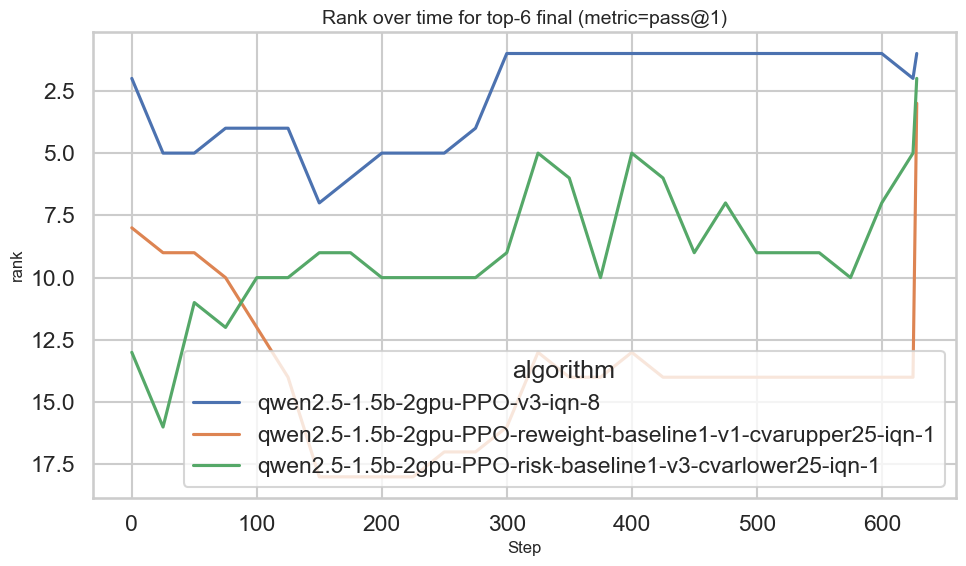

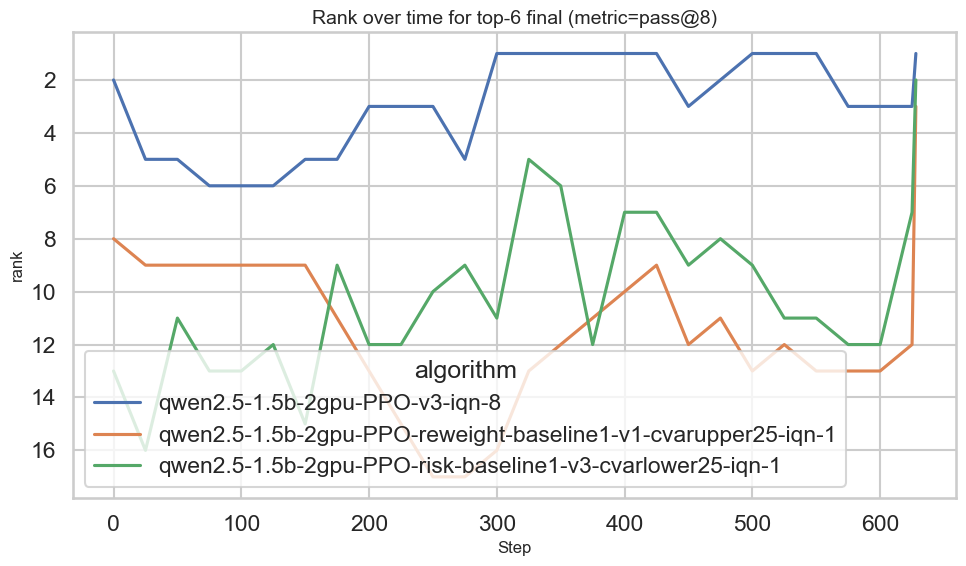

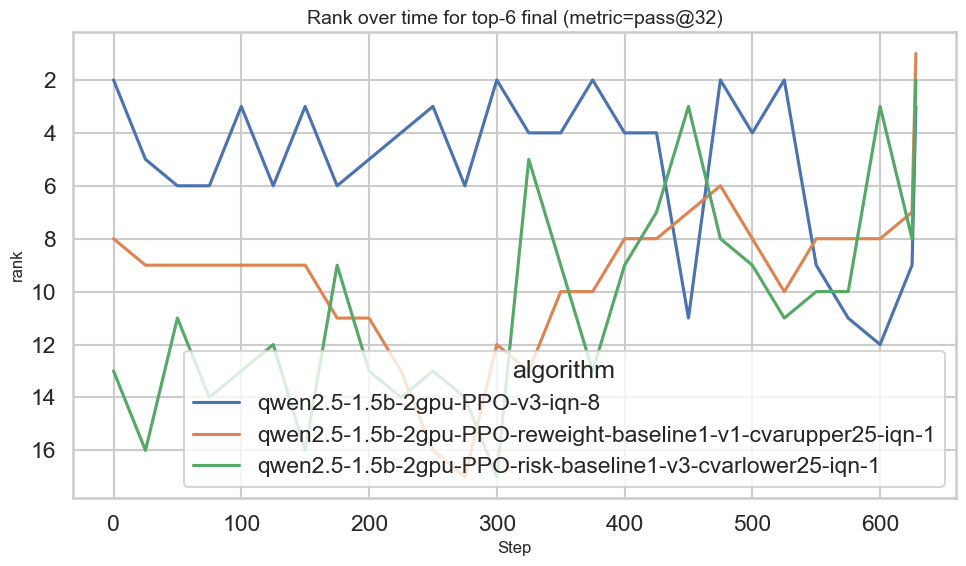

In [3]:
# Plot 1: rank over time for top-6 at final step
for metric in metrics:
    final = ranks[(ranks["metric"] == metric) & (ranks["Step"] == final_step)].sort_values("rank")
    tops = final["algorithm"].head(6).tolist()
    new_fig(f"Rank over time for top-6 final (metric={metric})")
    sns.lineplot(data=ranks[(ranks["metric"] == metric) & (ranks["algorithm"].isin(tops))], x="Step", y="rank", hue="algorithm")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94846/2934872880.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


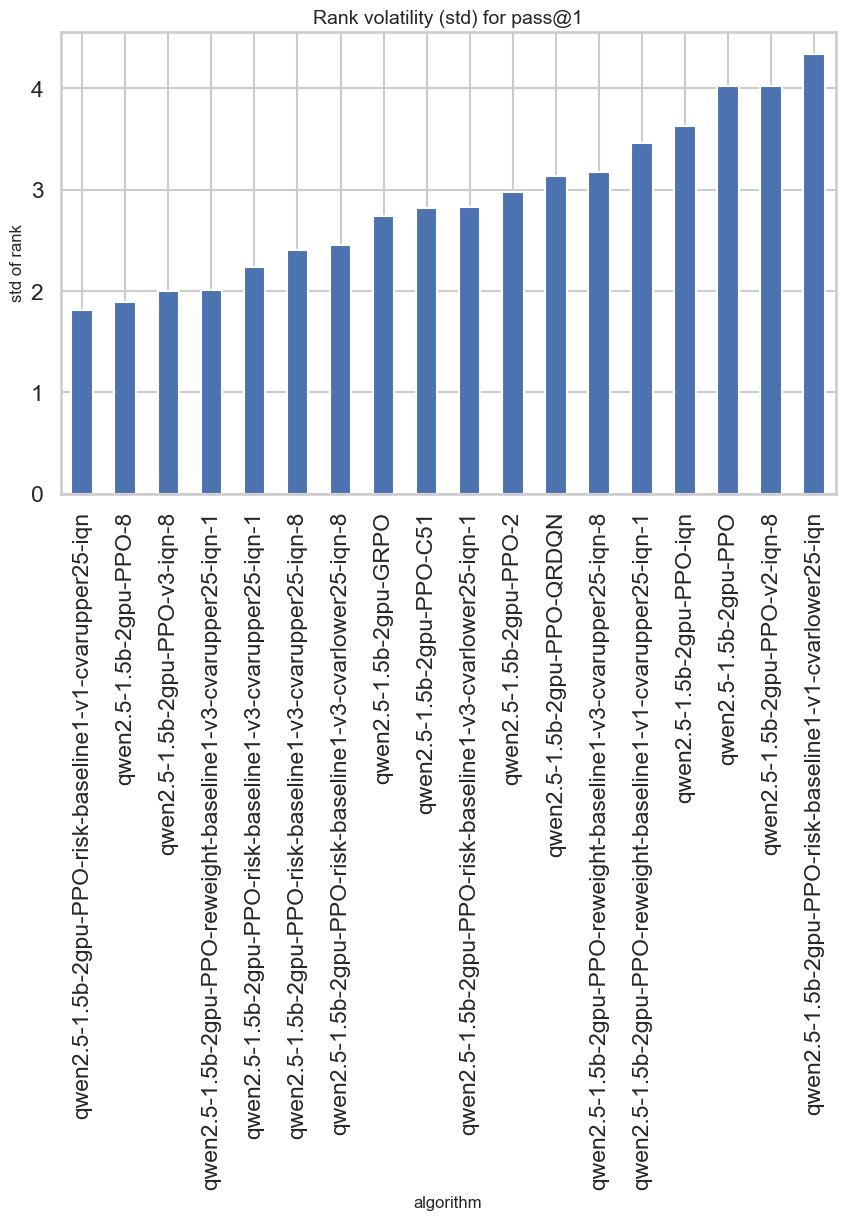

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94846/2934872880.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


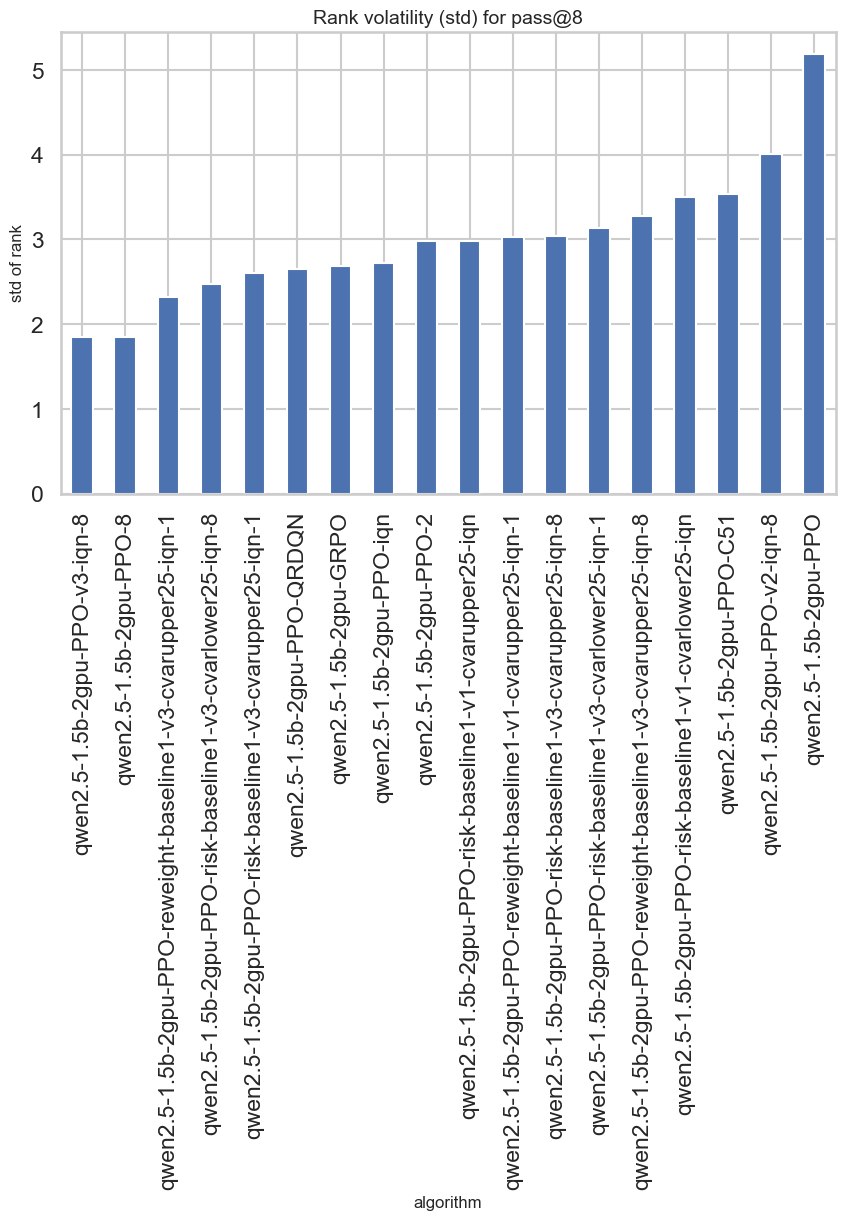

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94846/2934872880.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


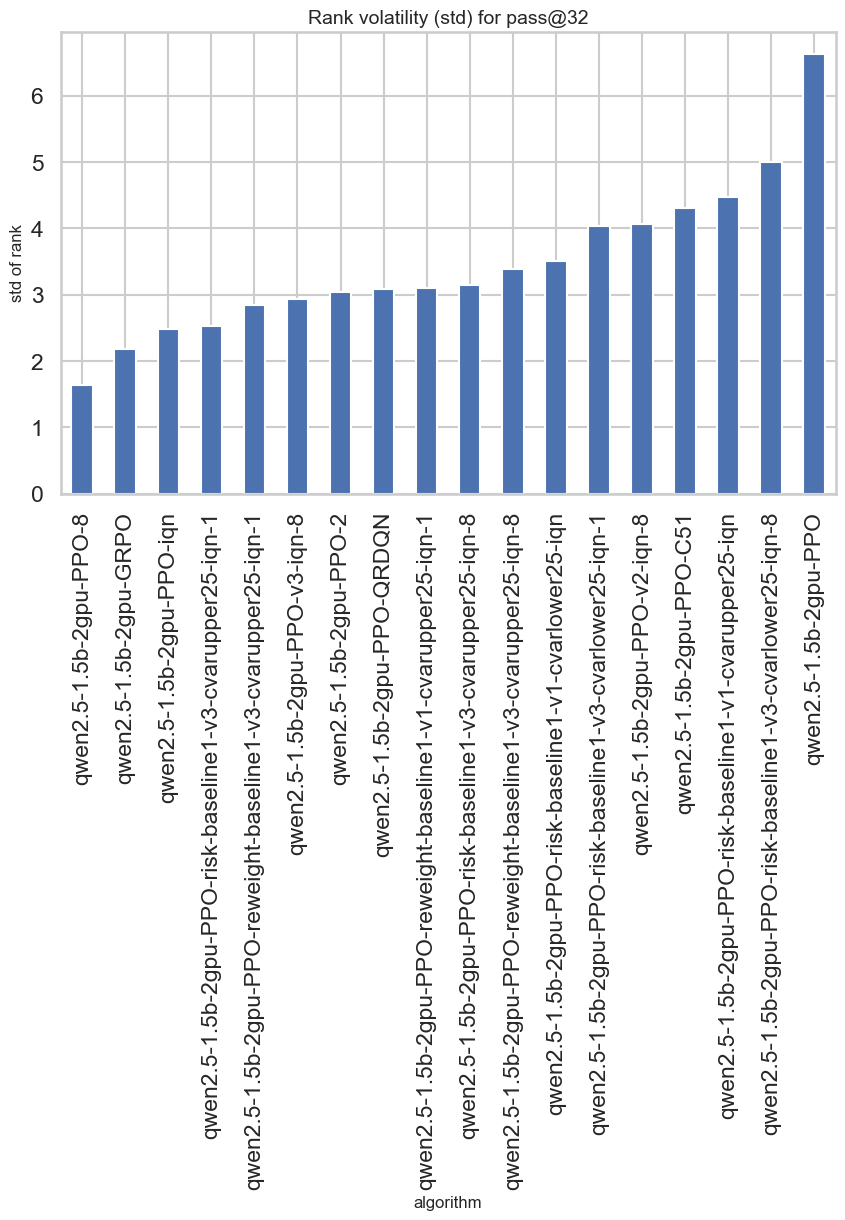

In [4]:
# Plot 2: rank volatility (std of rank over steps)
for metric in metrics:
    sub = ranks[ranks["metric"] == metric]
    volatility = sub.groupby("algorithm")["rank"].std().sort_values()
    new_fig(f"Rank volatility (std) for {metric}")
    volatility.plot(kind="bar")
    plt.ylabel("std of rank")
    plt.tight_layout()
    plt.show()


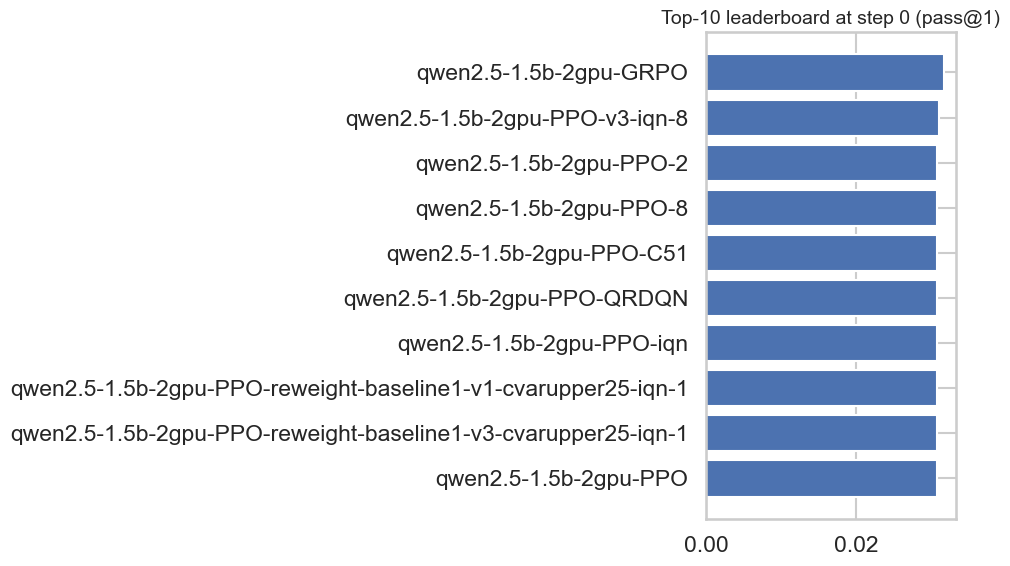

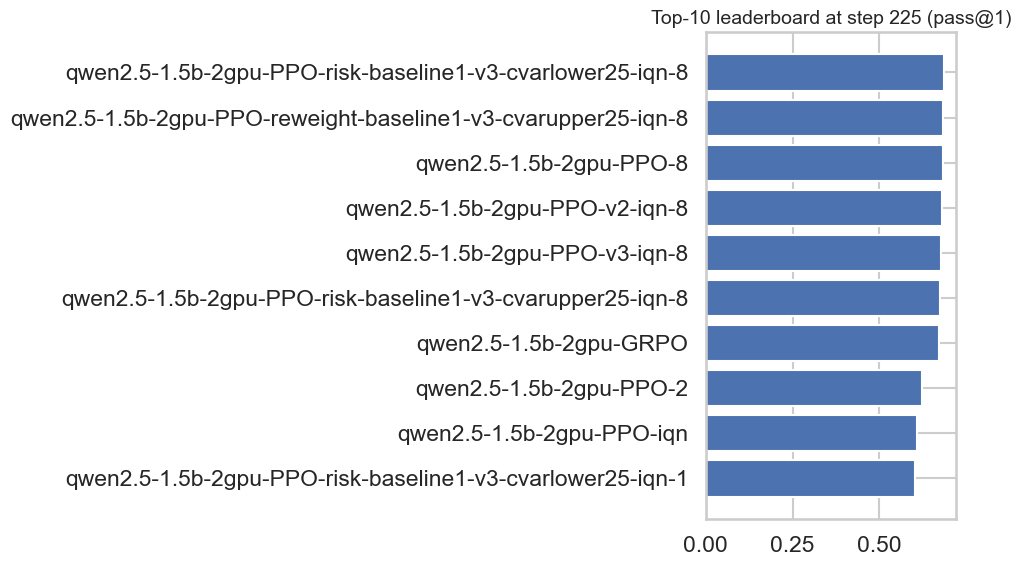

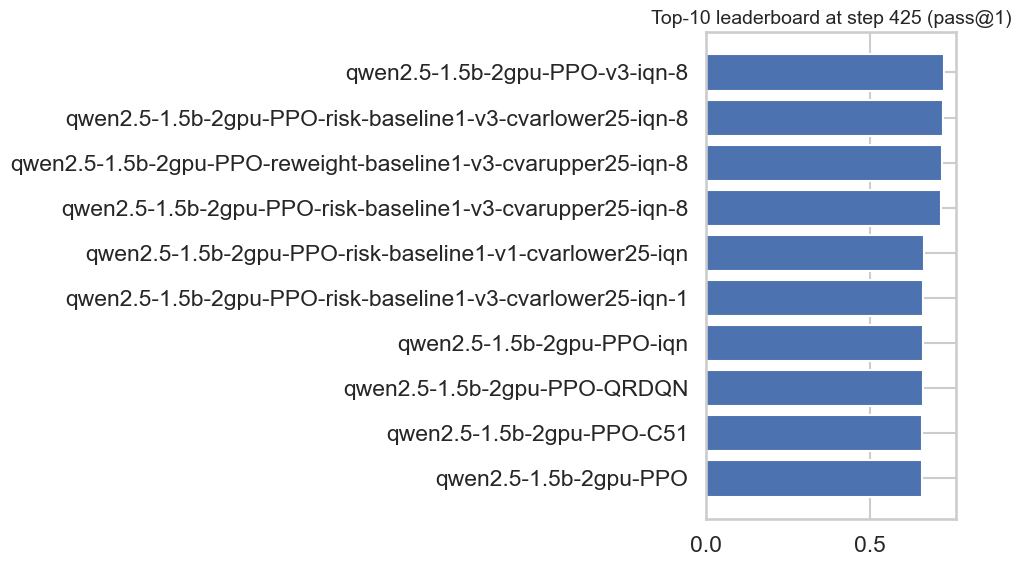

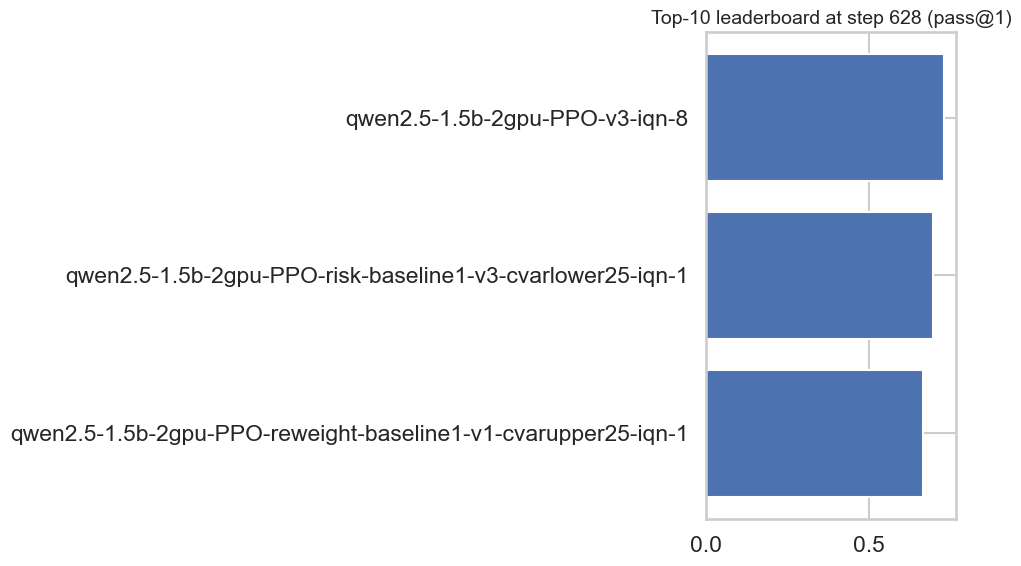

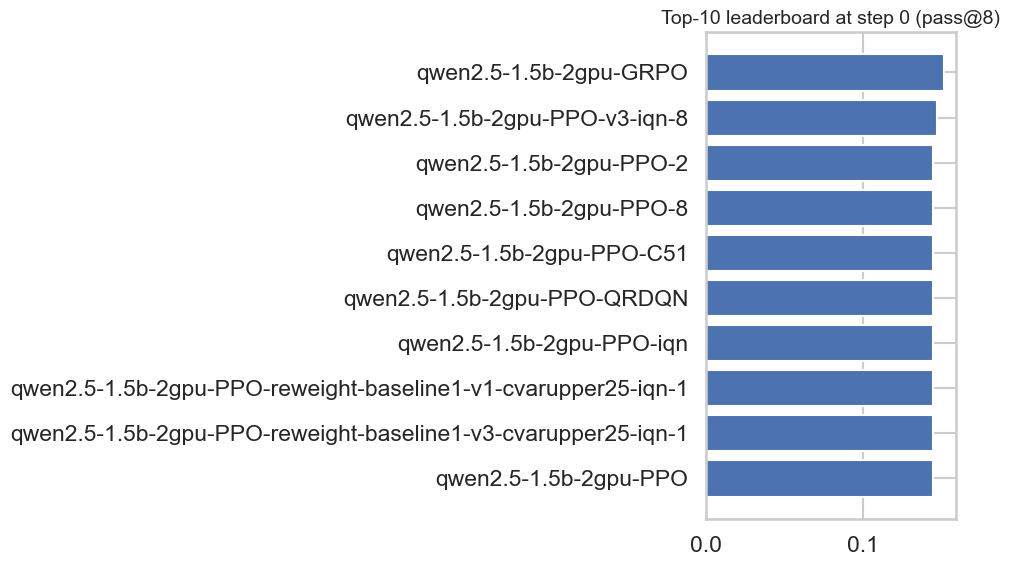

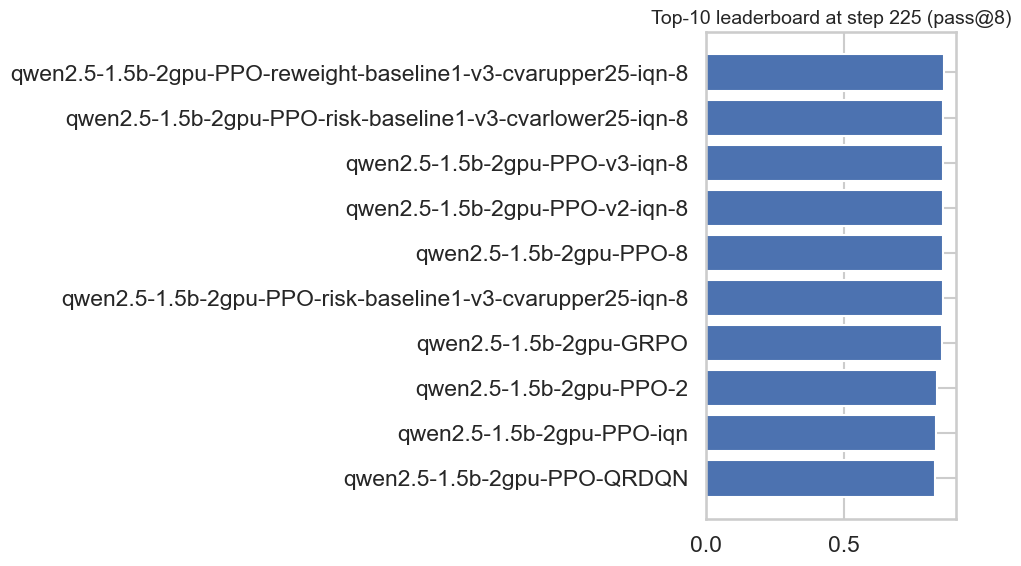

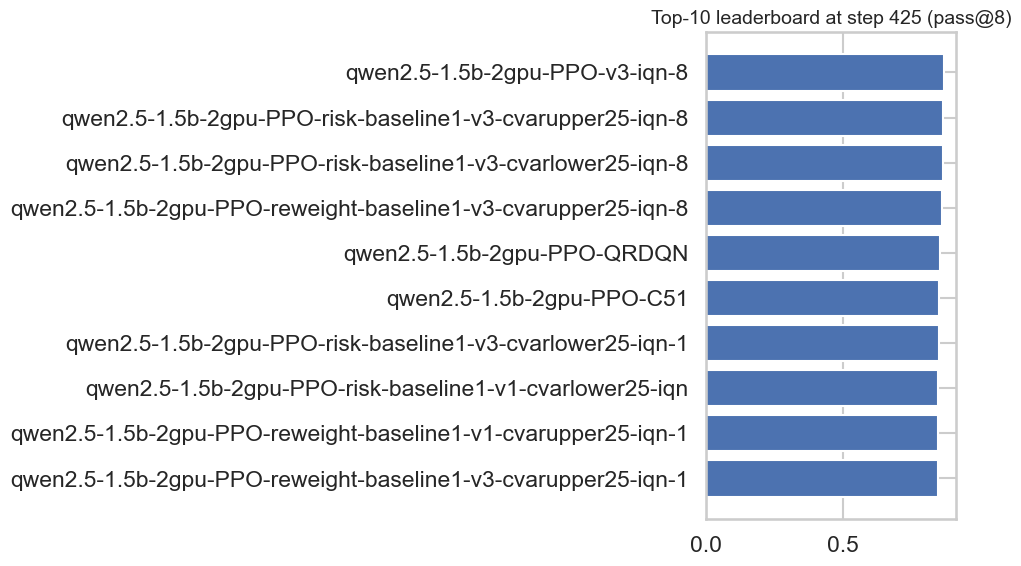

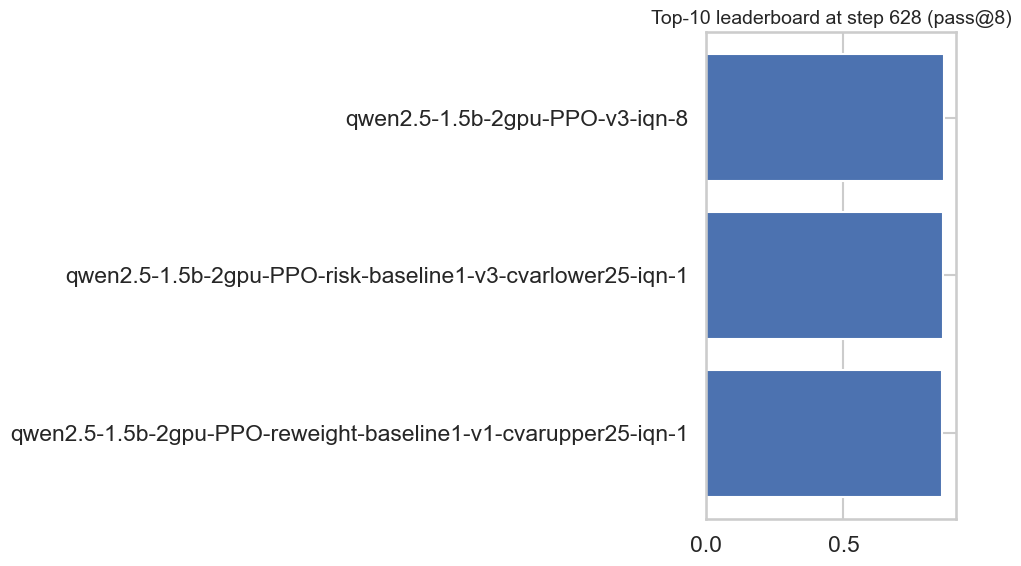

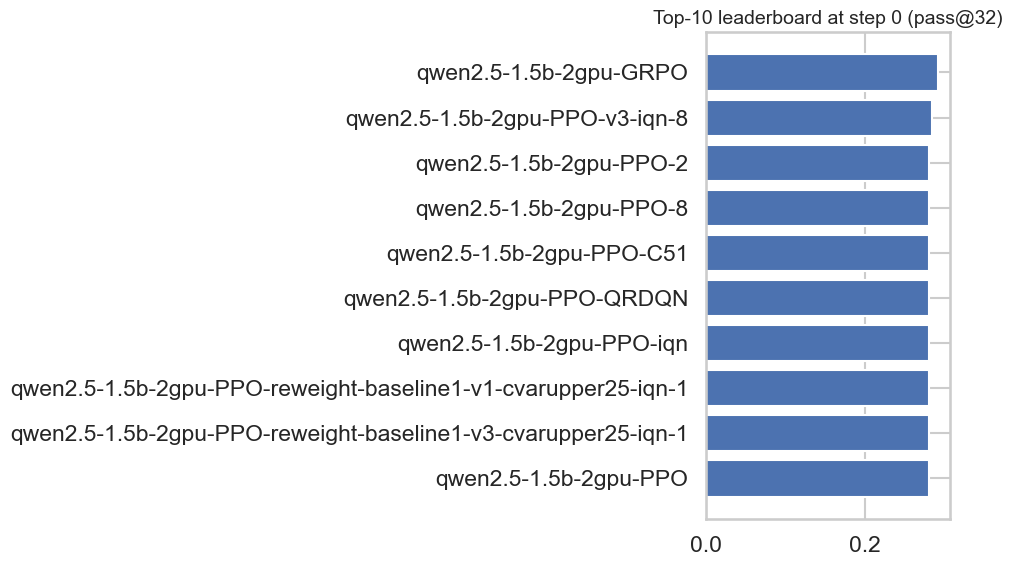

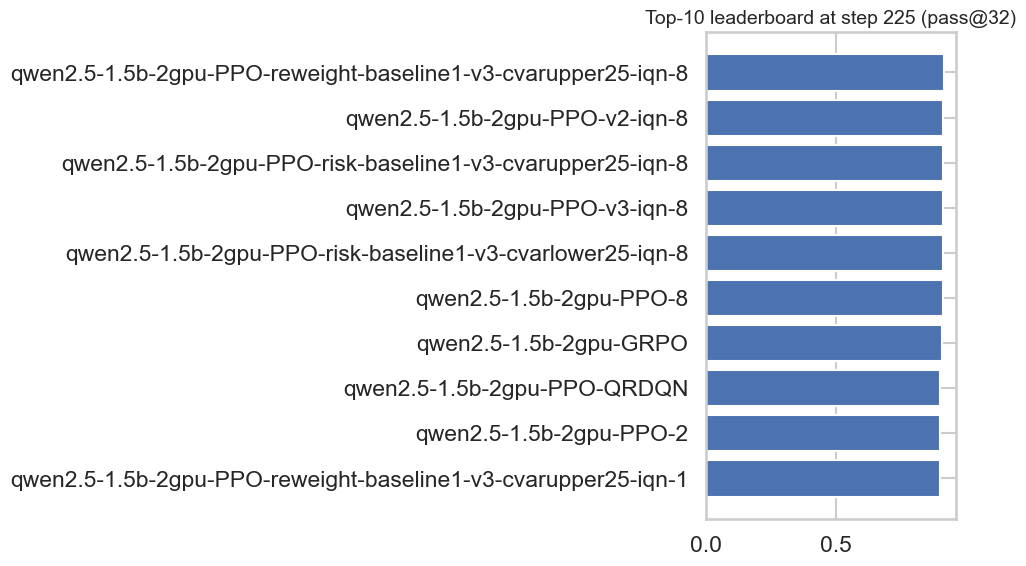

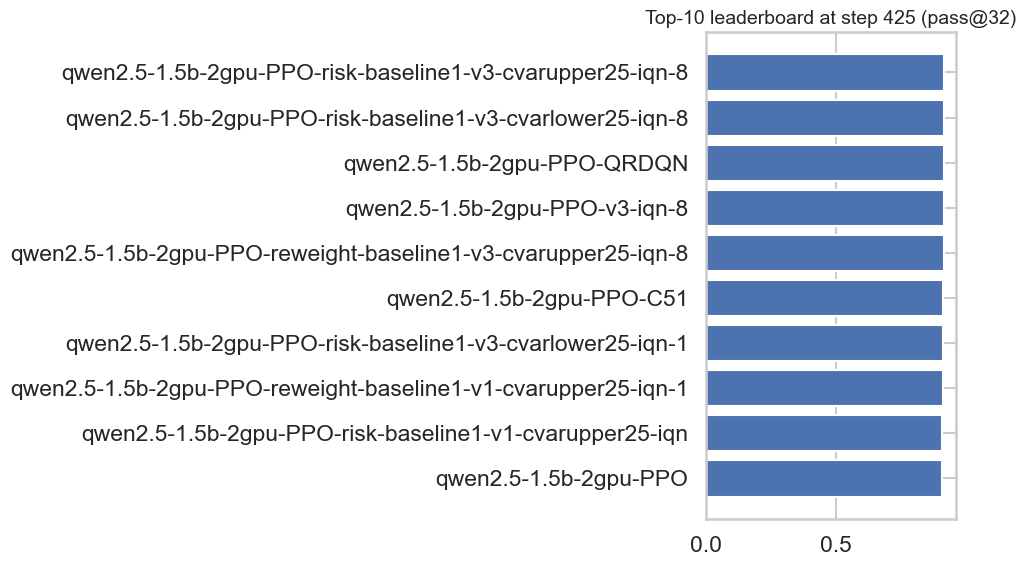

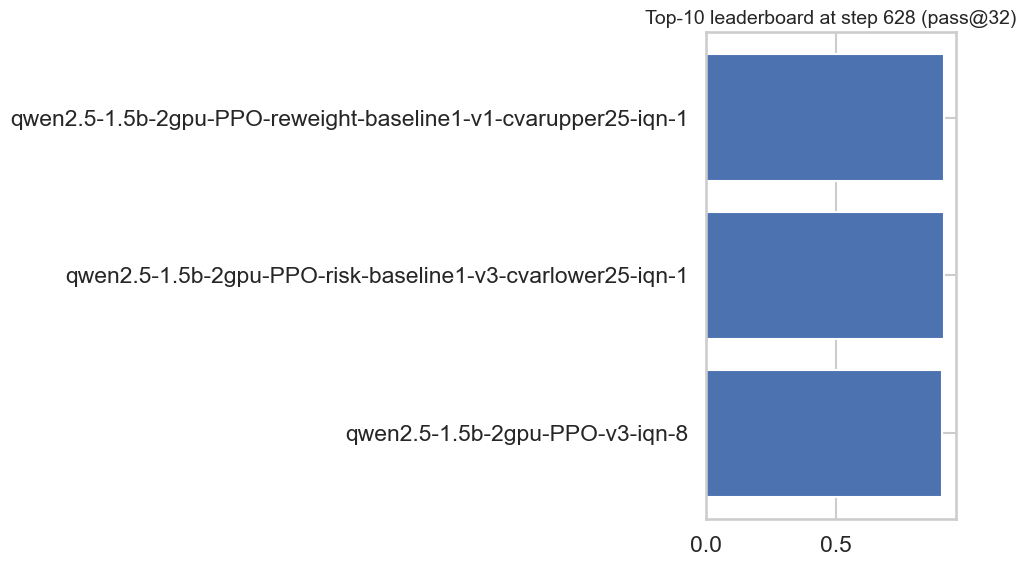

Generated 18 figures


In [5]:
# Plot 3: Bump chart style (top-10) at selected steps
for metric in metrics:
    steps = sorted(agg["Step"].unique())
    if len(steps) > 6:
        steps = [steps[0], steps[len(steps)//3], steps[(len(steps)*2)//3], steps[-1]]
    for step in steps:
        sub = ranks[(ranks["metric"] == metric) & (ranks["Step"] == step)].sort_values("rank").head(10)
        new_fig(f"Top-10 leaderboard at step {step} ({metric})")
        plt.barh(sub["algorithm"], sub["value"])
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

print(f"Generated {PLOT_COUNTER} figures")
